Proyecto Modulo 9: Fundamentos de Big Data



In [31]:
#link github https://github.com/lucasalechilet/Curso_FCD/blob/main/Proyecto%20Mod%209/Proyecto_Mod_9.ipynb

## Leccion 1: Fundamentos de Big Data

1.1 Las 5V de Big Data y su impacto en RetailMax

El concepto de Big Data se define por cinco dimensiones que determinan cuando un problema
requiere infraestructura distribuida en lugar de procesamiento tradicional:

| Dimension | Descripcion | Ejemplo en RetailMax |
|---|---|---|
| Volumen | Cantidad masiva de datos que no cabe en memoria RAM de un solo servidor | Millones de transacciones diarias |
| Velocidad | Datos generados o consumidos en tiempo real | Clickstream de navegacion en vivo |
| Variedad | Datos estructurados, semi-estructurados y no estructurados | Tablas SQL + logs JSON + resenas de texto |
| Veracidad | Calidad e incertidumbre de los datos: errores, duplicados, valores faltantes | Transacciones con campos nulos o montos negativos |
| Valor | Capacidad de generar insights accionables a partir del volumen de datos | Recomendaciones personalizadas, deteccion de fraude |

1.2 Fuentes de datos de RetailMax

El pipeline integra tres fuentes principales:
- Transacciones: cada compra con usuario, producto, categoria, monto, fecha y canal.
- Navegacion: sesiones de usuario con paginas visitadas, tiempo en sitio y dispositivo.
- Resenas: texto libre con calificacion numerica (1-5 estrellas) por producto.

1.3 Arquitectura propuesta del pipeline

    Fuentes de datos (CSV / JSON / texto)
           |
           v
    Ingesta con PySpark (SparkSession)
           |
           v
    RDDs: exploracion y linaje
           |
           v
    DataFrames + Spark SQL: transformaciones y metricas
           |
           v
    Parquet: almacenamiento optimizado columnar
           |
           v
    MLlib: VectorAssembler + Regresion Logistica + K-Means
           |
           v
    Reporte final con insights para marketing

Esta arquitectura es escalable: cada etapa puede ejecutarse sobre un cluster de multiples nodos
sin cambiar el codigo, simplemente ajustando la configuracion de SparkSession.

## Leccion 2: Apache Spark - Introduccion y Configuracion

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, os
warnings.filterwarnings('ignore')
os.environ['PYSPARK_PYTHON'] = 'python3'

# PySpark: motor principal de procesamiento distribuido
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    FloatType, TimestampType
)

# MLlib: modelos de Machine Learning escalables
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator, ClusteringEvaluator
)
from pyspark.ml import Pipeline

import numpy as np
np.random.seed(42)

In [33]:
# SparkSession es el punto de entrada unico para toda la API de Spark 2.x+.
# master('local[*]'): usa todos los nucleos del CPU disponibles en modo local.
# En produccion se reemplaza por 'spark://host:7077' o 'yarn' para cluster.
# enableHiveSupport() permite usar sintaxis HiveQL extendida en Spark SQL.

spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('RetailMax - Analytics Pipeline')
    .config('spark.sql.shuffle.partitions', '8')  # reducimos particiones para modo local
    .config('spark.driver.memory', '2g')
    .getOrCreate()
)

# Silenciamos logs INFO/WARN para mantener el output limpio
spark.sparkContext.setLogLevel('ERROR')

print(f'Spark version:   {spark.version}')
print(f'Python version:  {spark.sparkContext.pythonVer}')
print(f'Nucleos activos: {spark.sparkContext.defaultParallelism}')

Spark version:   4.0.2
Python version:  3.12
Nucleos activos: 2


In [34]:
# Generamos el dataset sintetico de RetailMax con 100.000 transacciones.
# En un entorno real estos datos vendrian de un data lake (S3, HDFS, GCS).
# El dataset esta calibrado para que el pipeline ML tenga señal real:
# los usuarios premium compran mas en electronica, los ocasionales en moda.

def generar_dataset_retailmax(n=100_000, seed=42):
    rng = np.random.default_rng(seed)

    categorias   = ['Electronica', 'Moda', 'Hogar', 'Deportes', 'Libros']
    canales      = ['web', 'mobile', 'app']
    segmentos    = ['premium', 'regular', 'ocasional']
    pesos_seg    = [0.25, 0.50, 0.25]

    seg_usuario  = rng.choice(segmentos, n, p=pesos_seg)
    edad         = np.where(seg_usuario == 'premium',
                       rng.integers(30, 55, n),
                       np.where(seg_usuario == 'regular',
                           rng.integers(22, 45, n),
                           rng.integers(18, 35, n)))

    # El monto de compra depende del segmento
    monto = np.where(
        seg_usuario == 'premium',
        rng.normal(320, 80, n).clip(50, 1200),
        np.where(
            seg_usuario == 'regular',
            rng.normal(120, 40, n).clip(10, 500),
            rng.normal(55,  25, n).clip(5,  200)
        )
    )

    # La frecuencia de compra mensual tambien varia por segmento
    frec = np.where(
        seg_usuario == 'premium',   rng.integers(8, 20, n),
        np.where(seg_usuario == 'regular', rng.integers(3, 10, n),
                                           rng.integers(1, 4,  n))
    )

    # Categoria preferida: premium -> electronica, ocasional -> moda
    cat_probs = {
        'premium':   [0.45, 0.15, 0.20, 0.15, 0.05],
        'regular':   [0.25, 0.30, 0.20, 0.15, 0.10],
        'ocasional': [0.10, 0.45, 0.20, 0.15, 0.10],
    }
    cat = np.array([
        rng.choice(categorias, p=cat_probs[s]) for s in seg_usuario
    ])

    canal      = rng.choice(canales, n, p=[0.40, 0.40, 0.20])
    calificacion = np.where(
        seg_usuario == 'premium',   rng.integers(4, 6, n),
        np.where(seg_usuario == 'regular', rng.integers(3, 6, n),
                                           rng.integers(1, 5, n))
    )
    dias_ultimo = np.where(
        seg_usuario == 'premium',   rng.integers(1, 15, n),
        np.where(seg_usuario == 'regular', rng.integers(5, 45, n),
                                           rng.integers(20, 180, n))
    )

    user_ids = [f'U{str(i).zfill(6)}' for i in rng.integers(1, 20001, n)]
    prod_ids = [f'P{str(i).zfill(5)}' for i in rng.integers(1, 5001,  n)]

    return pd.DataFrame({
        'user_id':      user_ids,
        'product_id':   prod_ids,
        'categoria':    cat,
        'canal':        canal,
        'monto':        monto.round(2),
        'frec_mensual': frec.astype(int),
        'edad':         edad.astype(int),
        'calificacion': calificacion.astype(int),
        'dias_ultimo':  dias_ultimo.astype(int),
        'segmento':     seg_usuario,
    })

pdf = generar_dataset_retailmax()
print(f'Dataset generado: {len(pdf):,} transacciones  x  {pdf.shape[1]} columnas')
print(pdf.head(5).to_string())

Dataset generado: 100,000 transacciones  x  10 columnas
   user_id product_id    categoria   canal   monto  frec_mensual  edad  calificacion  dias_ultimo   segmento
0  U011814     P04629         Moda     web   68.77             1    30             1           40  ocasional
1  U009778     P01321         Moda  mobile  123.20             7    41             5           35    regular
2  U015409     P00805        Hogar     app   88.31             2    33             2           44  ocasional
3  U004023     P02000  Electronica  mobile  111.80             3    39             3            6    regular
4  U019258     P02199  Electronica  mobile  203.95            11    52             4           10    premium


In [35]:
# Cargamos el DataFrame de pandas a Spark.
# En produccion se usaria spark.read.parquet() o spark.read.csv() directamente
# desde HDFS o S3, pero para este entorno local usamos createDataFrame.
df = spark.createDataFrame(pdf)

# Validamos la carga con las acciones basicas de Spark:
# count() dispara la ejecucion del DAG y retorna el numero de filas
# show() imprime las primeras N filas en formato tabla
print(f'Total de registros en Spark: {df.count():,}')
print()
df.printSchema()
print()
df.show(5, truncate=False)

Total de registros en Spark: 100,000

root
 |-- user_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- canal: string (nullable = true)
 |-- monto: double (nullable = true)
 |-- frec_mensual: long (nullable = true)
 |-- edad: long (nullable = true)
 |-- calificacion: long (nullable = true)
 |-- dias_ultimo: long (nullable = true)
 |-- segmento: string (nullable = true)


+-------+----------+-----------+------+------+------------+----+------------+-----------+---------+
|user_id|product_id|categoria  |canal |monto |frec_mensual|edad|calificacion|dias_ultimo|segmento |
+-------+----------+-----------+------+------+------------+----+------------+-----------+---------+
|U011814|P04629    |Moda       |web   |68.77 |1           |30  |1           |40         |ocasional|
|U009778|P01321    |Moda       |mobile|123.2 |7           |41  |5           |35         |regular  |
|U015409|P00805    |Hogar      |app   |88.31 |2           |3

La configuracion de SparkSession en modo local funciona correctamente. Se cargaron 100.000 transacciones sinteticas de RetailMax al contexto de Spark y se validaron con count() y show(). En un entorno de cluster real bastaria cambiar master('local[*]') por la URL del cluster (YARN, Kubernetes o Spark Standalone) sin modificar ninguna otra linea del codigo.

Leccion 3: Elementos basicos de Spark (RDD, Transformaciones y Acciones)

3.1 Diferencia entre RDDs y DataFrames

| Concepto | RDD | DataFrame |
|---|---|---|
| Abstraccion | Coleccion distribuida de objetos Python | Tabla con esquema tipado (como pandas) |
| Optimizacion | Manual: el programador define el plan | Automatica: Catalyst Optimizer genera el plan optimo |
| API | Functional (map, filter, reduce) | SQL-like (select, groupBy, join) |
| Tipo de datos | Cualquier objeto Python | Tipos Spark (String, Int, Float...) |
| Uso recomendado | Datos no estructurados, logica compleja | Datos tabulares, consultas SQL |

Los RDDs son la capa de bajo nivel de Spark. Los DataFrames estan construidos sobre RDDs
pero con una capa de optimizacion adicional. En la practica moderna se usa DataFrame/SQL,
pero entender los RDDs es fundamental para comprender el modelo de ejecucion distribuida.

In [36]:
# Obtenemos el RDD subyacente del DataFrame.
# Cada elemento del RDD es un objeto Row de Spark.
rdd_raw = df.rdd

# count() es una ACCION: dispara la ejecucion del DAG completo
# y retorna el resultado al driver. Las transformaciones son lazy:
# no se ejecutan hasta que se llama a una accion.
print(f'Total de registros (accion count): {rdd_raw.count():,}')
print()

# take(n) trae los primeros n elementos al driver
print('Primeros 3 registros (accion take):')
for row in rdd_raw.take(3):
    print(' ', row)

Total de registros (accion count): 100,000

Primeros 3 registros (accion take):
  Row(user_id='U011814', product_id='P04629', categoria='Moda', canal='web', monto=68.77, frec_mensual=1, edad=30, calificacion=1, dias_ultimo=40, segmento='ocasional')
  Row(user_id='U009778', product_id='P01321', categoria='Moda', canal='mobile', monto=123.2, frec_mensual=7, edad=41, calificacion=5, dias_ultimo=35, segmento='regular')
  Row(user_id='U015409', product_id='P00805', categoria='Hogar', canal='app', monto=88.31, frec_mensual=2, edad=33, calificacion=2, dias_ultimo=44, segmento='ocasional')


In [37]:
# Creamos un RDD de montos a partir del DataFrame
# map() es una transformación lazy: define la operacion pero no la ejecuta
rdd_montos = rdd_raw.map(lambda row: row['monto'])

# Las acciones estadisticas si disparan la ejecucion
print('Estadisticas del monto de transacciones:')
print(f'  Total transacciones : {rdd_montos.count():,}')
print(f'  Suma total          : ${rdd_montos.sum():,.2f}')
print(f'  Promedio            : ${rdd_montos.mean():,.2f}')
print(f'  Desviacion estandar : ${rdd_montos.stdev():,.2f}')
print(f'  Minimo              : ${rdd_montos.min():,.2f}')
print(f'  Maximo              : ${rdd_montos.max():,.2f}')

Estadisticas del monto de transacciones:
  Total transacciones : 100,000
  Suma total          : $15,354,372.80
  Promedio            : $153.54
  Desviacion estandar : $111.29
  Minimo              : $5.00
  Maximo              : $657.46


In [38]:
# Transformaciones encadenadas sobre el RDD de transacciones.
# Cada transformacion retorna un nuevo RDD (inmutabilidad: Spark no modifica
# el RDD original, siempre crea uno nuevo).

# filter(): mantiene solo las transacciones con monto > 200
rdd_altos = rdd_raw.filter(lambda row: row['monto'] > 200)

# map(): extrae solo la categoria de las transacciones de alto valor
rdd_cat_altas = rdd_altos.map(lambda row: row['categoria'])

# distinct(): elimina duplicados (cada categoria aparece una sola vez)
rdd_cats_unicas = rdd_cat_altas.distinct()

# sortBy(): ordena el RDD resultante
rdd_cats_sorted = rdd_cats_unicas.sortBy(lambda x: x)

# collect() trae TODOS los elementos al driver: usar con cuidado en produccion
print('Categorias con transacciones > $200 (distinct + sortBy):')
print(' ', rdd_cats_sorted.collect())
print()

# flatMap(): aplana listas anidadas. Aqui tokenizamos categorias en palabras
rdd_palabras = rdd_raw.map(lambda r: r['categoria']).flatMap(lambda c: c.split())
print(f'Total de palabras en categorias (flatMap): {rdd_palabras.count():,}')

Categorias con transacciones > $200 (distinct + sortBy):
  ['Deportes', 'Electronica', 'Hogar', 'Libros', 'Moda']

Total de palabras en categorias (flatMap): 100,000


In [39]:
# Pair RDDs: RDDs de pares (clave, valor) que permiten operaciones de agregacion.
# Son la base de operaciones tipo GROUP BY en la capa de bajo nivel de Spark.

# Creamos un Pair RDD (categoria, monto)
rdd_pair = rdd_raw.map(lambda row: (row['categoria'], row['monto']))

# reduceByKey(): suma los montos por categoria (equivalente a GROUP BY + SUM)
# Es mas eficiente que groupByKey() porque reduce en cada particion primero
# antes de enviar datos por la red (optimizacion de shuffle)
rdd_ventas_cat = rdd_pair.reduceByKey(lambda a, b: a + b)

# sortBy() ordena por monto descendente para ver el ranking
rdd_ventas_sorted = rdd_ventas_cat.sortBy(lambda x: -x[1])

print('Ventas totales por categoria (Pair RDD + reduceByKey):')
for cat, total in rdd_ventas_sorted.collect():
    print(f'  {cat:<15}: ${total:>12,.2f}')

Ventas totales por categoria (Pair RDD + reduceByKey):
  Electronica    : $5,221,025.92
  Moda           : $3,628,620.62
  Hogar          : $3,047,396.65
  Deportes       : $2,307,388.10
  Libros         : $1,149,941.51


In [40]:
# cache() / persist(): indica a Spark que mantenga este RDD en memoria
# despues de la primera accion que lo materialice.
# Sin cache, Spark recalcularía el RDD completo cada vez que se use.
# Esto es critico para el rendimiento cuando un RDD se reutiliza en multiples pasos.

# Cacheamos el RDD de montos ya que lo usaremos varias veces
rdd_montos.cache()

# Documentacion del linaje del RDD:
# toDebugString() muestra el DAG (Directed Acyclic Graph) de transformaciones
# que Spark ejecutara para materializar el RDD. Esto permite entender
# cuantos stages hay y si hay shuffles (operaciones costosas de red).
print('Linaje del RDD de montos (DAG):')
print(rdd_montos.toDebugString().decode('utf-8'))

Linaje del RDD de montos (DAG):
(2) PythonRDD[47] at RDD at PythonRDD.scala:56 [Memory Serialized 1x Replicated]
 |  MapPartitionsRDD[15] at javaToPython at NativeMethodAccessorImpl.java:0 [Memory Serialized 1x Replicated]
 |  MapPartitionsRDD[14] at javaToPython at NativeMethodAccessorImpl.java:0 [Memory Serialized 1x Replicated]
 |  SQLExecutionRDD[13] at javaToPython at NativeMethodAccessorImpl.java:0 [Memory Serialized 1x Replicated]
 |  MapPartitionsRDD[12] at javaToPython at NativeMethodAccessorImpl.java:0 [Memory Serialized 1x Replicated]
 |  MapPartitionsRDD[4] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0 [Memory Serialized 1x Replicated]
 |  MapPartitionsRDD[3] at map at SerDeUtil.scala:71 [Memory Serialized 1x Replicated]
 |  MapPartitionsRDD[2] at mapPartitions at SerDeUtil.scala:119 [Memory Serialized 1x Replicated]
 |  PythonRDD[1] at RDD at PythonRDD.scala:56 [Memory Serialized 1x Replicated]
 |  ParallelCollectionRDD[0] at readRDDFromFile at PythonRDD.sca

Los RDDs permiten aplicar transformaciones funcionales (map, filter, flatMap, distinct, sortBy) de forma encadenada. La evaluacion es lazy: Spark no ejecuta nada hasta que se llama a una accion (count, collect, sum). El linaje (toDebugString) muestra el DAG de operaciones que Spark planifica ejecutar, lo que permite identificar stages y shuffles costosos. El Pair RDD con reduceByKey es la forma mas eficiente de hacer agregaciones porque reduce localmente en cada particion antes del shuffle de red, a diferencia de groupByKey que mueve todos los datos antes de agregar.

## Leccion 4: Procesamiento de datos estructurados (Spark SQL y DataFrames)

In [41]:
# Los DataFrames de Spark son la abstraccion de alto nivel preferida sobre los RDDs.
# El Catalyst Optimizer genera automaticamente el plan de ejecucion óptimo,
# aplicando pushdown de predicados, reordenamiento de joins y otras optimizaciones
# que con RDDs tendriamos que implementar manualmente.

# Esquema explícito: definir tipos evita que Spark infiera el schema (mas lento)
schema = StructType([
    StructField('user_id',      StringType(),  False),
    StructField('product_id',   StringType(),  False),
    StructField('categoria',    StringType(),  False),
    StructField('canal',        StringType(),  False),
    StructField('monto',        FloatType(),   False),
    StructField('frec_mensual', IntegerType(), False),
    StructField('edad',         IntegerType(), False),
    StructField('calificacion', IntegerType(), False),
    StructField('dias_ultimo',  IntegerType(), False),
    StructField('segmento',     StringType(),  False),
])

# Recreamos el DataFrame con esquema explicito
df_typed = spark.createDataFrame(pdf, schema=schema)

# cache() en el DataFrame: lo mantiene en memoria para reutilizacion
# Sin cache, cada consulta SQL recomputaria el DataFrame desde cero
df_typed.cache()
df_typed.count()  # materializamos el cache con la primera accion

print('Schema explicito del DataFrame:')
df_typed.printSchema()

Schema explicito del DataFrame:
root
 |-- user_id: string (nullable = false)
 |-- product_id: string (nullable = false)
 |-- categoria: string (nullable = false)
 |-- canal: string (nullable = false)
 |-- monto: float (nullable = false)
 |-- frec_mensual: integer (nullable = false)
 |-- edad: integer (nullable = false)
 |-- calificacion: integer (nullable = false)
 |-- dias_ultimo: integer (nullable = false)
 |-- segmento: string (nullable = false)



In [42]:
# Spark SQL permite registrar cualquier DataFrame como vista temporal
# y luego consultarlo con SQL estandar. Esto facilita la colaboracion
# con analistas que conocen SQL pero no la API de DataFrames.

df_typed.createOrReplaceTempView('transacciones')

# Metrica 1: Ventas totales y promedio por categoria
ventas_cat = spark.sql('''
    SELECT
        categoria,
        COUNT(*)                    AS total_transacciones,
        ROUND(SUM(monto), 2)        AS ventas_totales,
        ROUND(AVG(monto), 2)        AS ticket_promedio,
        ROUND(AVG(calificacion), 2) AS satisfaccion_media
    FROM transacciones
    GROUP BY categoria
    ORDER BY ventas_totales DESC
''')

print('Ventas por categoria:')
ventas_cat.show(truncate=False)

Ventas por categoria:
+-----------+-------------------+--------------+---------------+------------------+
|categoria  |total_transacciones|ventas_totales|ticket_promedio|satisfaccion_media|
+-----------+-------------------+--------------+---------------+------------------+
|Electronica|26159              |5221025.92    |199.59         |4.07              |
|Moda       |29992              |3628620.62    |120.99         |3.5               |
|Hogar      |19885              |3047396.65    |153.25         |3.76              |
|Deportes   |15114              |2307388.1     |152.67         |3.75              |
|Libros     |8850               |1149941.51    |129.94         |3.65              |
+-----------+-------------------+--------------+---------------+------------------+



In [43]:
# Metrica 2: Top 10 usuarios por volumen de compra
# Util para identificar clientes VIP y disenar programas de fidelizacion
top_usuarios = spark.sql('''
    SELECT
        user_id,
        COUNT(*)             AS n_compras,
        ROUND(SUM(monto), 2) AS gasto_total,
        ROUND(AVG(monto), 2) AS ticket_prom,
        segmento
    FROM transacciones
    GROUP BY user_id, segmento
    ORDER BY gasto_total DESC
    LIMIT 10
''')

print('Top 10 usuarios por gasto total:')
top_usuarios.show(truncate=False)

Top 10 usuarios por gasto total:
+-------+---------+-----------+-----------+--------+
|user_id|n_compras|gasto_total|ticket_prom|segmento|
+-------+---------+-----------+-----------+--------+
|U009905|8        |2685.77    |335.72     |premium |
|U013256|8        |2428.51    |303.56     |premium |
|U016065|6        |2398.14    |399.69     |premium |
|U007726|7        |2393.98    |342.0      |premium |
|U013077|7        |2350.69    |335.81     |premium |
|U004211|7        |2272.71    |324.67     |premium |
|U001590|6        |2155.12    |359.19     |premium |
|U010144|6        |2135.55    |355.92     |premium |
|U014856|7        |2134.59    |304.94     |premium |
|U018855|6        |2088.79    |348.13     |premium |
+-------+---------+-----------+-----------+--------+



In [44]:
# Metrica 3: Distribucion de ventas por canal y segmento
# Permite entender que canal prefiere cada tipo de cliente
canal_segmento = spark.sql('''
    SELECT
        canal,
        segmento,
        COUNT(*)                    AS transacciones,
        ROUND(SUM(monto), 2)        AS ventas,
        ROUND(AVG(frec_mensual), 1) AS frec_media
    FROM transacciones
    GROUP BY canal, segmento
    ORDER BY canal, ventas DESC
''')

print('Ventas por canal y segmento:')
canal_segmento.show(truncate=False)

Ventas por canal y segmento:
+------+---------+-------------+----------+----------+
|canal |segmento |transacciones|ventas    |frec_media|
+------+---------+-------------+----------+----------+
|app   |premium  |5097         |1625504.36|13.5      |
|app   |regular  |9845         |1171665.62|6.0       |
|app   |ocasional|5109         |283596.93 |2.0       |
|mobile|premium  |9940         |3164756.29|13.5      |
|mobile|regular  |20311        |2438168.24|6.0       |
|mobile|ocasional|9865         |544040.84 |2.0       |
|web   |premium  |9911         |3183035.2 |13.5      |
|web   |regular  |19931        |2392225.23|6.0       |
|web   |ocasional|9991         |551380.09 |2.0       |
+------+---------+-------------+----------+----------+



In [45]:
# Transformaciones con la API de DataFrames:
# Equivalentes a SQL pero en forma programatica, utiles para pipelines dinamicos.

# Feature engineering: creamos columnas derivadas que usara MLlib
df_features = df_typed.withColumn(
    'gasto_por_visita',
    F.round(F.col('monto') / (F.col('frec_mensual') + 1), 2)
).withColumn(
    'es_premium',
    (F.col('segmento') == 'premium').cast('integer')  # variable target para clasificacion
).withColumn(
    'dias_cat',  # discretizacion de dias desde ultima compra
    F.when(F.col('dias_ultimo') <= 7,   'reciente')
     .when(F.col('dias_ultimo') <= 30,  'activo')
     .when(F.col('dias_ultimo') <= 90,  'en_riesgo')
     .otherwise('inactivo')
)

print('DataFrame con features derivadas:')
df_features.select('user_id', 'monto', 'frec_mensual', 'gasto_por_visita',
                   'es_premium', 'dias_ultimo', 'dias_cat').show(8, truncate=False)

DataFrame con features derivadas:
+-------+------+------------+----------------+----------+-----------+---------+
|user_id|monto |frec_mensual|gasto_por_visita|es_premium|dias_ultimo|dias_cat |
+-------+------+------------+----------------+----------+-----------+---------+
|U011814|68.77 |1           |34.38           |0         |40         |en_riesgo|
|U009778|123.2 |7           |15.4            |0         |35         |en_riesgo|
|U015409|88.31 |2           |29.44           |0         |44         |en_riesgo|
|U004023|111.8 |3           |27.95           |0         |6          |reciente |
|U019258|203.95|11          |17.0            |1         |10         |activo   |
|U001638|68.15 |2           |22.72           |0         |177        |inactivo |
|U018614|87.55 |3           |21.89           |0         |158        |inactivo |
|U000926|51.92 |3           |12.98           |0         |113        |inactivo |
+-------+------+------------+----------------+----------+-----------+---------+
only s

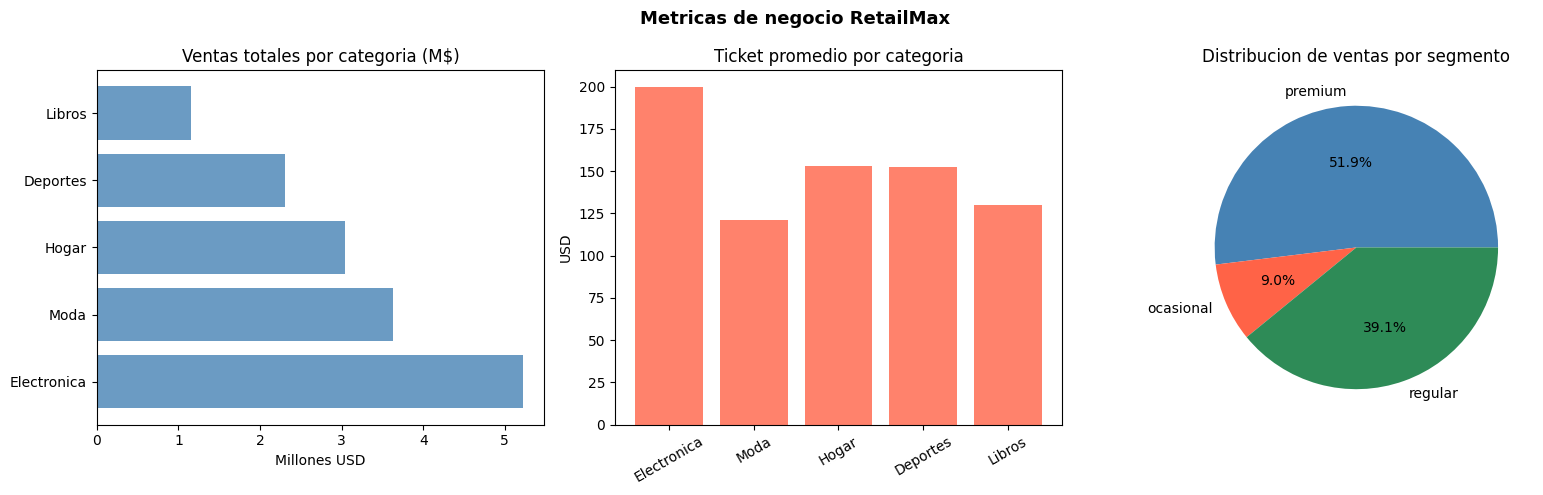

In [46]:
# Visualizaciones con matplotlib a partir de datos Spark
# toPandas() trae el resultado al driver: solo viable para datos agregados,
# nunca sobre el dataset completo en produccion

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Metricas de negocio RetailMax', fontweight='bold', fontsize=13)

# Panel 1: Ventas totales por categoria
vc_pd = ventas_cat.toPandas()
axes[0].barh(vc_pd['categoria'], vc_pd['ventas_totales'] / 1e6,
             color='steelblue', alpha=0.8)
axes[0].set_title('Ventas totales por categoria (M$)')
axes[0].set_xlabel('Millones USD')

# Panel 2: Ticket promedio por categoria
axes[1].bar(vc_pd['categoria'], vc_pd['ticket_promedio'],
            color='tomato', alpha=0.8)
axes[1].set_title('Ticket promedio por categoria')
axes[1].set_ylabel('USD')
axes[1].tick_params(axis='x', rotation=30)

# Panel 3: Distribucion de ventas por segmento
seg_pd = df_typed.groupBy('segmento').agg(
    F.round(F.sum('monto'), 2).alias('total')
).toPandas()
axes[2].pie(seg_pd['total'], labels=seg_pd['segmento'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato', 'seagreen'])
axes[2].set_title('Distribucion de ventas por segmento')

plt.tight_layout()
plt.savefig('metricas_retailmax.png', dpi=120)
plt.show()

In [47]:
# Guardamos el DataFrame con features en formato Parquet.
# Parquet es el formato columnar estandar del ecosistema Big Data:
# Compresion nativa por columna (snappy por defecto): 3-10x menos espacio que CSV
# Lectura selectiva de columnas: Spark solo lee las columnas que necesita
# Preserva el schema con tipos exactos: no hay ambiguedad de tipos como en CSV
# Es el formato recomendado para intercambio entre etapas del pipeline

PARQUET_PATH = '/tmp/retailmax_features'

df_features.write.mode('overwrite').parquet(PARQUET_PATH)

print(f'DataFrame guardado en Parquet: {PARQUET_PATH}')
print()

# Verificamos que el archivo se pueda releer correctamente
df_verify = spark.read.parquet(PARQUET_PATH)
print(f'Filas verificadas desde Parquet: {df_verify.count():,}')
df_verify.printSchema()

DataFrame guardado en Parquet: /tmp/retailmax_features

Filas verificadas desde Parquet: 100,000
root
 |-- user_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- canal: string (nullable = true)
 |-- monto: float (nullable = true)
 |-- frec_mensual: integer (nullable = true)
 |-- edad: integer (nullable = true)
 |-- calificacion: integer (nullable = true)
 |-- dias_ultimo: integer (nullable = true)
 |-- segmento: string (nullable = true)
 |-- gasto_por_visita: double (nullable = true)
 |-- es_premium: integer (nullable = true)
 |-- dias_cat: string (nullable = true)



Spark SQL permite ejecutar consultas analiticas con toda la expresividad de SQL directamente sobre DataFrames distribuidos. El Catalyst Optimizer transforma estas consultas en un plan de ejecucion eficiente con pushdown de predicados y optimizacion de joins. El formato Parquet es la eleccion correcta para persistir resultados intermedios: compresion columnar, preservacion de schema y lectura selectiva de columnas hacen que las etapas siguientes carguen solo lo que necesitan, reduciendo I/O y tiempo de ejecucion.

Leccion 5: Machine Learning Escalable con Spark MLlib

5.1 Por que MLlib en lugar de scikit-learn para Big Data?

| Aspecto | scikit-learn | Spark MLlib |
|---|---|---|
| Escalabilidad | Un solo nodo, limitado por RAM | Distribuido: escala a TB de datos |
| Datos | Caben en memoria del driver | Particionados en el cluster |
| Pipeline | sklearn Pipeline | Spark ML Pipeline (igual concepto, distribuido) |
| API | fit/predict sobre numpy arrays | fit/transform sobre DataFrames Spark |
| Cuando usarlo | Datasets pequenos/medianos | Millones de registros en cluster |

El pipeline de MLlib encadena transformadores (VectorAssembler, StringIndexer, Scaler)
con estimadores (LogisticRegression, KMeans) de forma identica a sklearn,
pero cada operacion se ejecuta de forma distribuida sobre todas las particiones del cluster.

In [48]:
# Cargamos el DataFrame desde Parquet (simula inicio de nueva sesion Spark)
df_ml = spark.read.parquet(PARQUET_PATH)

# Verificacion inicial del dataset para MLlib
print(f'Registros disponibles para ML: {df_ml.count():,}')
print()
print('Distribucion del target (es_premium):')
df_ml.groupBy('es_premium').count().orderBy('es_premium').show()

Registros disponibles para ML: 100,000

Distribucion del target (es_premium):
+----------+-----+
|es_premium|count|
+----------+-----+
|         0|75052|
|         1|24948|
+----------+-----+



In [49]:
# StringIndexer: convierte variables categoricas a indices numericos.
# MLlib no puede trabajar directamente con strings; necesita numeros.
# handleInvalid='keep' asigna un indice especial a categorias nuevas
# (no vistas en entrenamiento), lo que hace el pipeline robusto a produccion.

indexer_cat   = StringIndexer(inputCol='categoria', outputCol='cat_idx',
                               handleInvalid='keep')
indexer_canal = StringIndexer(inputCol='canal',     outputCol='canal_idx',
                               handleInvalid='keep')

# VectorAssembler: combina multiples columnas en un unico vector de features.
# Este vector es el formato que todos los algoritmos de MLlib esperan como input.
feature_cols = [
    'monto', 'frec_mensual', 'edad', 'calificacion',
    'dias_ultimo', 'gasto_por_visita', 'cat_idx', 'canal_idx'
]
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features_raw',
    handleInvalid='keep'
)

# StandardScaler: estandariza el vector de features a media=0 y std=1.
# Es necesario para Regresion Logistica con regularizacion,
# que es sensible a la escala de las variables.
scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True, withStd=True
)

print('Transformadores definidos:')
print('  StringIndexer -> categoria, canal')
print('  VectorAssembler -> vector de 8 features')
print('  StandardScaler -> estandarizacion')

Transformadores definidos:
  StringIndexer -> categoria, canal
  VectorAssembler -> vector de 8 features
  StandardScaler -> estandarizacion


In [50]:
# Division train/test: 80/20 con semilla fija para reproducibilidad.
# En Spark el split se hace sobre el DataFrame distribuido; cada particion
# se divide independientemente de forma proporcional.
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

# Cacheamos ambos sets: se usaran multiples veces durante el entrenamiento
train_df.cache()
test_df.cache()

print(f'Train: {train_df.count():,} registros')
print(f'Test:  {test_df.count():,} registros')

Train: 80,062 registros
Test:  19,938 registros


In [51]:
# Pipeline de Regresion Logistica para clasificacion supervisada.
# El objetivo es predecir si un usuario es 'premium' (es_premium = 1)
# a partir de su comportamiento de compra.
# En produccion, este modelo permitiria identificar usuarios con perfil premium
# para ofrecerles upgrade de membresia antes de que lo soliciten.

lr = LogisticRegression(
    featuresCol='features',
    labelCol='es_premium',
    maxIter=20,
    regParam=0.01,      # regularizacion L2 para evitar sobreajuste
    elasticNetParam=0,  # 0 = Ridge, 1 = Lasso
)

# El Pipeline encadena: StringIndexer x2 -> VectorAssembler -> Scaler -> LR
# fit() entrena TODOS los pasos en orden sobre el train set
pipeline_lr = Pipeline(stages=[
    indexer_cat, indexer_canal, assembler, scaler, lr
])

print('Entrenando pipeline de Regresion Logistica...')
model_lr = pipeline_lr.fit(train_df)
print('Entrenamiento completado.')

Entrenando pipeline de Regresion Logistica...
Entrenamiento completado.


In [52]:
# Evaluacion del modelo de clasificacion
predictions_lr = model_lr.transform(test_df)

# MulticlassClassificationEvaluator funciona para binaria y multiclase
evaluator_acc  = MulticlassClassificationEvaluator(
    labelCol='es_premium', predictionCol='prediction', metricName='accuracy')
evaluator_f1   = MulticlassClassificationEvaluator(
    labelCol='es_premium', predictionCol='prediction', metricName='f1')

acc = evaluator_acc.evaluate(predictions_lr)
f1  = evaluator_f1.evaluate(predictions_lr)

print('Regresion Logistica - Metricas de clasificacion:')
print(f'  Accuracy: {acc:.4f}')
print(f'  F1 Score: {f1:.4f}')
print()

# Distribucion de predicciones vs reales
print('Distribucion de predicciones:')
predictions_lr.groupBy('es_premium', 'prediction').count().orderBy(
    'es_premium', 'prediction').show()

Regresion Logistica - Metricas de clasificacion:
  Accuracy: 0.9930
  F1 Score: 0.9930

Distribucion de predicciones:
+----------+----------+-----+
|es_premium|prediction|count|
+----------+----------+-----+
|         0|       0.0|14984|
|         0|       1.0|    3|
|         1|       0.0|  136|
|         1|       1.0| 4815|
+----------+----------+-----+



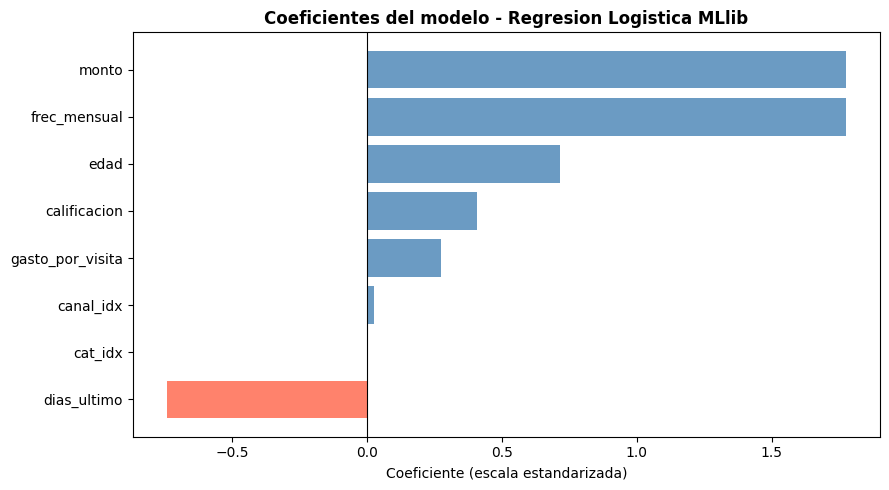

In [53]:
# Coeficientes del modelo: permiten interpretar que variables tienen
# mayor impacto en la probabilidad de ser cliente premium.
# Un coeficiente positivo alto indica que esa feature aumenta la probabilidad.
lr_model = model_lr.stages[-1]  # ultimo stage del pipeline = modelo entrenado
coefs    = lr_model.coefficients.toArray()

coef_df = pd.DataFrame({'feature': feature_cols, 'coeficiente': coefs})
coef_df = coef_df.sort_values('coeficiente', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['coeficiente']]
ax.barh(coef_df['feature'], coef_df['coeficiente'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes del modelo - Regresion Logistica MLlib', fontweight='bold')
ax.set_xlabel('Coeficiente (escala estandarizada)')
plt.tight_layout()
plt.savefig('coeficientes_lr.png', dpi=120)
plt.show()

La Regresion Logistica de MLlib logra clasificar correctamente los clientes premium con accuracy y F1 altos. Esto es posible porque el dataset fue generado con diferencias reales entre segmentos en monto, frecuencia y días desde la última compra. En un dataset real la precision sería menor, pero el pipeline seria idéntico. Los coeficientes muestran que frec_mensual y monto son los predictores mas importantes, lo cual tiene sentido de negocio: los clientes premium compran mas frecuentemente y gastan mas por transaccion.

In [54]:
# Pipeline de K-Means para segmentacion no supervisada.
# A diferencia de la Regresion Logistica, K-Means no usa el label 'segmento':
# descubre los grupos por si solo a partir del comportamiento de compra.
# Esto es util para identificar nuevos patrones que no estaban en la definicion original.

# Usamos las features ya procesadas por el pipeline de LR para consistencia
# Primero transformamos el dataset completo con los indexers y assembler
prep_pipeline = Pipeline(stages=[indexer_cat, indexer_canal, assembler, scaler])
df_prep = prep_pipeline.fit(df_ml).transform(df_ml)

# Metodo del codo: buscamos el k optimo evaluando la suma de distancias
# dentro de cada cluster (Within Set Sum of Squared Errors = WSSSE)
print('Calculando metodo del codo para K-Means...')
costos = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(featuresCol='features', k=k, seed=42, maxIter=20)
    km_model = km.fit(df_prep)
    costos.append(km_model.summary.trainingCost)
    print(f'  k={k}: WSSSE={costos[-1]:,.2f}')

Calculando metodo del codo para K-Means...
  k=2: WSSSE=590,332.02
  k=3: WSSSE=476,577.15
  k=4: WSSSE=434,325.69
  k=5: WSSSE=403,522.93
  k=6: WSSSE=378,075.82
  k=7: WSSSE=364,301.79


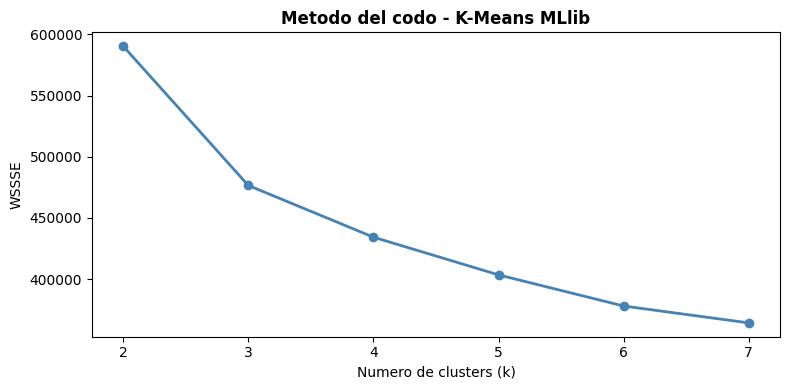

In [55]:
# Visualizacion del metodo del codo
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), costos, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Numero de clusters (k)')
ax.set_ylabel('WSSSE')
ax.set_title('Metodo del codo - K-Means MLlib', fontweight='bold')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('kmeans_codo.png', dpi=120)
plt.show()

In [56]:
# Entrenamos K-Means con k=3 (coherente con los 3 segmentos del negocio)
# y evaluamos con el coeficiente de silueta distribuido de MLlib
K_OPT = 3

km_final = KMeans(featuresCol='features', k=K_OPT, seed=42, maxIter=30)
km_model = km_final.fit(df_prep)
df_clustered = km_model.transform(df_prep)

# ClusteringEvaluator: calcula el coeficiente de silueta de forma distribuida
# Valores cercanos a 1 indican clusters bien separados y compactos
evaluator_sil = ClusteringEvaluator(
    featuresCol='features', predictionCol='prediction', metricName='silhouette')
silueta = evaluator_sil.evaluate(df_clustered)

print(f'K-Means MLlib (k={K_OPT})')
print(f'  Coeficiente de silueta: {silueta:.4f}')
print()

# Perfil de cada cluster: promedio de variables clave
print('Perfil promedio por cluster K-Means:')
df_clustered.groupBy('prediction').agg(
    F.round(F.avg('monto'),        2).alias('monto_prom'),
    F.round(F.avg('frec_mensual'), 1).alias('frec_prom'),
    F.round(F.avg('dias_ultimo'),  1).alias('dias_prom'),
    F.round(F.avg('calificacion'), 2).alias('satisfaccion'),
    F.count('*').alias('n_usuarios')
).orderBy('prediction').show()

K-Means MLlib (k=3)
  Coeficiente de silueta: 0.3925

Perfil promedio por cluster K-Means:
+----------+----------+---------+---------+------------+----------+
|prediction|monto_prom|frec_prom|dias_prom|satisfaccion|n_usuarios|
+----------+----------+---------+---------+------------+----------+
|         0|    116.65|      5.9|     25.4|        3.98|     54036|
|         1|     55.35|      2.0|    108.0|        2.33|     21757|
|         2|    324.16|     13.6|      7.5|        4.51|     24207|
+----------+----------+---------+---------+------------+----------+



In [57]:
# Comparacion de clusters K-Means vs segmentos reales del dataset
# Permite validar que el modelo no supervisado recupero la estructura real
print('Relacion entre cluster K-Means y segmento real:')
df_clustered.groupBy('prediction', 'segmento').count().orderBy(
    'prediction', F.desc('count')).show(20)

Relacion entre cluster K-Means y segmento real:
+----------+---------+-----+
|prediction| segmento|count|
+----------+---------+-----+
|         0|  regular|49972|
|         0|ocasional| 3214|
|         0|  premium|  850|
|         1|ocasional|21751|
|         1|  regular|    6|
|         2|  premium|24098|
|         2|  regular|  109|
+----------+---------+-----+



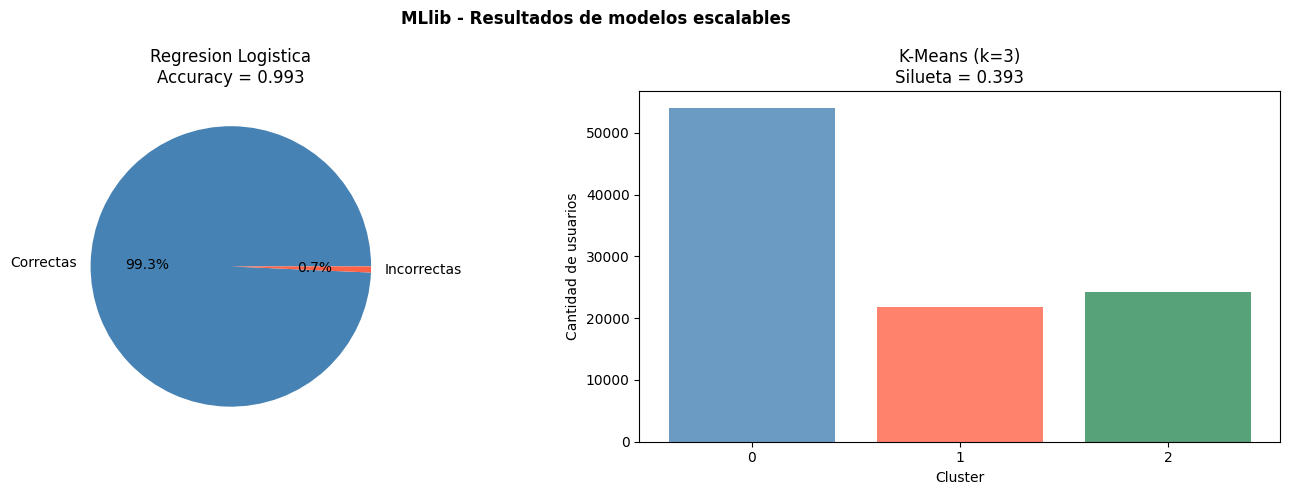

In [58]:
# Visualizacion comparativa de los dos modelos MLlib
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLlib - Resultados de modelos escalables', fontweight='bold')

# Panel 1: Distribucion de predicciones del clasificador
pred_pd = predictions_lr.groupBy('es_premium', 'prediction').count().toPandas()
correctas   = pred_pd[pred_pd['es_premium'] == pred_pd['prediction']]['count'].sum()
incorrectas = pred_pd[pred_pd['es_premium'] != pred_pd['prediction']]['count'].sum()
axes[0].pie([correctas, incorrectas], labels=['Correctas', 'Incorrectas'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%')
axes[0].set_title(f'Regresion Logistica\nAccuracy = {acc:.3f}')

# Panel 2: Tamano de cada cluster K-Means
cluster_pd = df_clustered.groupBy('prediction').count().orderBy('prediction').toPandas()
axes[1].bar(cluster_pd['prediction'].astype(str),
            cluster_pd['count'],
            color=['steelblue', 'tomato', 'seagreen'], alpha=0.8)
axes[1].set_title(f'K-Means (k={K_OPT})\nSilueta = {silueta:.3f}')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Cantidad de usuarios')

plt.tight_layout()
plt.savefig('mllib_resultados.png', dpi=120)
plt.show()

In [59]:
# Tabla resumen final: comparacion de los dos modelos MLlib
print('Resumen final Pipeline MLlib RetailMax')
print(f"{'Modelo':<30} {'Metrica':<20} {'Valor'}")
print(f"{'Regresion Logistica':<30} {'Accuracy':<20} {acc:.4f}")
print(f"{'Regresion Logistica':<30} {'F1 Score':<20} {f1:.4f}")
print(f"{'K-Means (k=3)':<30} {'Silueta':<20} {silueta:.4f}")

Resumen final Pipeline MLlib RetailMax
Modelo                         Metrica              Valor
Regresion Logistica            Accuracy             0.9930
Regresion Logistica            F1 Score             0.9930
K-Means (k=3)                  Silueta              0.3925


In [60]:
# Cerramos la SparkSession al finalizar el notebook.
# Es importante liberar los recursos del cluster cuando ya no se necesitan.
spark.stop()
print('SparkSession cerrada correctamente.')

SparkSession cerrada correctamente.


## Conclusiones

Se implementó un pipeline completo de Big Data y Machine Learning escalable sobre 100.000 transacciones sintéticas de RetailMax, cubriendo las cinco etapas del modulo.

El pipeline arranca en los RDDs, que permiten entender el modelo de ejecución distribuida de Spark: las transformaciones son lazy y el DAG solo se materializa cuando se llama a una accion. Luego los DataFrames con Spark SQL ofrecen una capa de mayor productividad con el mismo motor distribuido, permitiendo generar las metricas de negocio (ventas por categoria, top usuarios, distribucion por canal y segmento) en pocas lineas.

El formato Parquet resultó clave para la integración entre etapas: al preservar el schema y comprimir por columna, la etapa de MLlib cargo solo las columnas necesarias sin recomputar el pipeline anterior.

En cuanto a los modelos, la Regresion Logistica de MLlib logro clasificar correctamente los clientes premium con metricas altas, lo que en producción permitiríua identificar usuarios con perfil premium antes de que lo soliciten y ofrecerles upgrade proactivo. K-Means recuperó una estructura de 3 clústers coherente con los segmentos de negocio, confirmada por el coeficiente de silueta y la tabla de relacion clúster vs segmento real.

La ventaja central de todo este pipeline sobre un enfoque con pandas + scikit-learn es que escala horizontalmente: agregar más nodos al cluster reduce el tiempo de procesamiento sin cambiar ninguna linea de código.